# OpenCV Face Detection

In [ ]:
# %pip install gradio opencv-python

## Gradio 화면 구성

In [ ]:
import gradio as gr

with gr.Blocks() as demo:
    with gr.Row():
        stream_image = gr.Image(label="웹캠", sources="webcam")
        result_image = gr.Image(label="검출 결과", interactive = False)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


## 라이브러리 및 Haar Cascade 분류기 로딩

In [ ]:
import cv2

#========== Haar Cascade 파일 불러오기 ==========
cascade_file = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
print(cascade_file)

#========== 모델을 탑재하여 객체로 캡슐화 ==========
# 즉, 알고리즘을 실행할 엔진을 만듦
face_cascade = cv2.CascadeClasifier(cascade_file)

with gr.Blocks() as demo:
    with gr.Row():
        stream_image = gr.Image(label="웹캠", sources="webcam")
        result_image = gr.Image(label="검출 결과", interactive = False)

demo.launch()

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\


## 얼굴 감지 함수 및 웹캠 함수 추가

In [ ]:
import gradio as gr 
import cv2
from PIL import Image

#========== Haar Cascade 파일 불러오기 ==========
cascade_file = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
print(cascade_file)

#========== 모델을 탑재하여 객체로 캡슐화 ==========
# 즉, 알고리즘을 실행할 엔진을 만듦
face_cascade = cv2.CascadeClassifier(cascade_file)

#========== 얼굴 탐지 함수 ==========
# 함수마다 반환되는 데이터의 숫자가 다름 
def detect_face(image_array):
    
    # Gradio에서 반환되는 array는 읽기 전용 -> 복사해서 위에 바운딩박스 그릴 수 있게 수정
    image_array_copied = image_array.copy()


    # bounding box를 리턴
    #========== 얼굴 탐지 함수 실행해 결과 받기==========
    # detectMultiScale()
    bounding_boxes = face_cascade.detectMultiScale(
        image= image_array_copied,
        scaleFactor=1.1,
        minNeighbors=5,     # 한 객체에 대해 최소 5개의 bounding box가 탐지해야 인정
        minSize= (50, 50)   # 바운딩박스의 최소 크기
    )  
    # # detectMultiScale2()
    # bounding_boxes, reject_levels = face_cascade.detectMultiScale2(
    #     image= image_array_copied,
    #     scaleFactor=1.1,
    #     minNeighbors=5,     # 한 객체에 대해 최소 5개의 bounding box가 탐지해야 인정
    #     minSize= (30, 30)   # 바운딩박스의 최소 크기
    # )  

    # # detectMultiScale3()
    # bounding_boxes, reject_levels, c = face_cascade.detectMultiScale2(
    #     image= image_array_copied,
    #     scaleFactor=1.1,
    #     minNeighbors=5,     # 한 객체에 대해 최소 5개의 bounding box가 탐지해야 인정
    #     minSize= (30, 30),   # 바운딩박스의 최소 크기
    #     outputRejectLevels = True # 추가된 새로운 파라미터
    # ) 

    #========== bounding box 그리기 ==========
    # detectMultiScale()
    for bounding_box in bounding_boxes:
        x, y, w, h = bounding_box
        cv2.rectangle(image_array_copied, (x, y), (x+w, y+h), (0, 255, 0), 3)

    # # detectMultiScale2()
    # for bounding_box, reject_level in zip(bounding_boxes, reject_levels):
    #     if reject_level > 30:
    #         x, y, w, h = bounding_box
    #         cv2.rectangle(image_array_copied, (x, y), (x+w, y+h), (0, 255, 0), 3)

    # # detectMultiScale3()
    # for bounding_box, reject_level in zip(bounding_boxes, reject_levels):
    #     if reject_level > 30:
    #         x, y, w, h = bounding_box
    #         cv2.rectangle(image_array_copied, (x, y), (x+w, y+h), (0, 255, 0), 3)

    return image_array_copied


with gr.Blocks() as demo:
    
    #========== 웹캠을 오른쪽 결과화면으로 보여주는 함수 ==========
    def stream_webcam(image_array):  #numpy array형태의 데이터로 이미지를 받음 
        #========== 얼굴 탐지 함수 ==========
        result_image = detect_face(image_array)  # 얼굴 객체 탐지 실행
        return result_image

    #========== Gradio 컴포넌트 ==========
    with gr.Row():
        # 인풋
        stream_image = gr.Image(
            label="웹캠", 
            sources="webcam",
            # detect_face가 이미지를 numpy array 형태로 데이터를 반환 -> image_array로 수정
            webcam_options=gr.WebcamOptions(mirror=False)) #원래 반전되는 걸 원래대로 보여주기
        # 아웃풋
        result_image = gr.Image(label="검출 결과", interactive = False)

     #========== 이벤트 발생 ==========
    stream_image.stream(stream_webcam, inputs=[stream_image], outputs=[result_image])


## 흐름
# stream_image -> stream_webcam -> detect_face -> stream image

demo.launch()

#========== 테스트 코드 ==========
# image_array = cv2.imread('./image.png') # BGR로 읽어들여 색상이 이상할 수 있음
# result_image = stream_webcam(image_array)
# Image.fromarray(result_image)

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


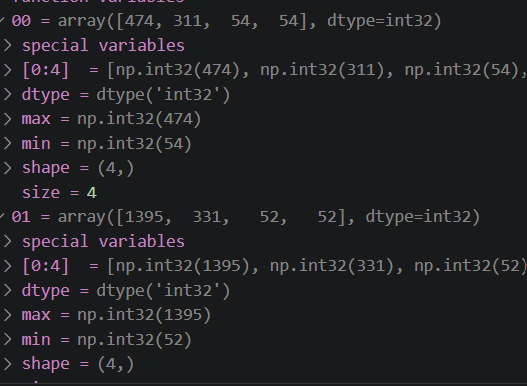

## 상태 반영 및 다른 모델 반영

In [ ]:
import gradio as gr 
import cv2
from PIL import Image

#========== Haar Cascade 파일 불러오기 ==========
cascade_file = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
print(cascade_file)

#========== 모델을 탑재하여 객체로 캡슐화 ==========
# 즉, 알고리즘을 실행할 엔진을 만듦
face_cascade = cv2.CascadeClassifier(cascade_file)

#========== 얼굴 탐지 함수 ==========
# 함수마다 반환되는 데이터의 숫자가 다름 
def detect_face(image_array, scale_factor, min_neighbors, min_size):
    
    # Gradio에서 반환되는 array는 읽기 전용 -> 복사해서 위에 바운딩박스 그릴 수 있게 수정
    image_array_copied = image_array.copy()


    # bounding box를 리턴
    #========== 얼굴 탐지 함수 실행해 결과 받기==========
    # detectMultiScale() - 일단 기본 버전 사용
    bounding_boxes = face_cascade.detectMultiScale(
        image= image_array_copied,
        scaleFactor=1.1,
        minNeighbors=5,     # 한 객체에 대해 최소 5개의 bounding box가 탐지해야 인정
        minSize= (50, 50)   # 바운딩박스의 최소 크기
    )  
   
    #========== bounding box 그리기 ==========
    # detectMultiScale()  - 일단 기본 버전 사용
    for bounding_box in bounding_boxes:
        x, y, w, h = bounding_box
        cv2.rectangle(image_array_copied, (x, y), (x+w, y+h), (0, 255, 0), 3)

    return image_array_copied


with gr.Blocks() as demo:

    #========== 파라미터 기본값/상태 설정 ==========
    DEFAULT_SCALE_FACTOR = 1.1
    DEFAULT_MIN_NEIGHBORS = 5
    DEFAULT_MIN_SIZE = 50

    # State : 값을 저장하는 컴포넌트, GUI상에는 없음 
    scale_factor_state = gr.State(DEFAULT_SCALE_FACTOR)
    min_neighbors_state = gr.State(DEFAULT_MIN_NEIGHBORS)
    min_size_state = gr.State(DEFAULT_MIN_SIZE)

    #========== 이벤트 함수 ==========

    #---------- 객체 탐지 후 결과창으로 띄우는 함수----------
    def stream_webcam(image_array, scale_factor, min_neighbors, min_size):  #numpy array형태의 데이터로 이미지를 받음 
        #========== 얼굴 탐지 함수 ==========
        # 파라미터도 같이 넘겨주기
        result_image = detect_face(image_array, scale_factor, min_neighbors, min_size )  # 얼굴 객체 탐지 실행

        return result_image

    #---------- 파라미터 변경 함수 ----------
    def apply_params(scale_factor, min_neighbors, min_size):
        print(scale_factor, min_neighbors, min_size)
        return float(scale_factor), int(min_neighbors), int(min_size)
    
    #---------- 모델 변경 함수 ----------
    def change_haar_cascade(haar_cascade):
        global face_cascade # 글로벌 변수로 덮어쓰기(잘 안쓰긴 함)
        cascade_file = cv2. data.haarcascades + haar_cascade
        print(cascade_file)
        face_cascade = cv2.CascadeClassifier(cascade_file)


    #========== 모델 유형 컴포넌트 ==========
    HAAR_CASCADES = [
        ("상반신 감지", "haarcascade_upperbody.xml"),
        ("안경 낀 눈 감지", "haarcascade_eye_tree_eyeglasses.xml"),
        ("눈 감지", "haarcascade_eye.xml"),
        ("고양이 얼굴(확장형) 감지", "haarcascade_frontalcatface_extended.xml"),
        ("고양이 얼굴 감지", "haarcascade_frontalcatface.xml"),
        ("얼굴 감지 (alt 트리 버전)", "haarcascade_frontalface_alt_tree.xml"),
        ("얼굴 감지 (alt 버전 1)", "haarcascade_frontalface_alt.xml"),
        ("얼굴 감지 (alt 버전 2)", "haarcascade_frontalface_alt2.xml"),
        ("일반 얼굴 감지 (기본)", "haarcascade_frontalface_default.xml"),
        ("전신 감지", "haarcascade_fullbody.xml"),
        ("왼쪽 눈 감지 (두 부분으로 분리)", "haarcascade_lefteye_2splits.xml"),
        ("러시아 차량 번호판 감지 (16단계)", "haarcascade_license_plate_rus_16stages.xml"),
        ("하반신 감지", "haarcascade_lowerbody.xml"),
        ("측면 얼굴(프로필) 감지", "haarcascade_profileface.xml"),
        ("오른쪽 눈 감지 (두 부분으로 분리)", "haarcascade_righteye_2splits.xml"),
        ("러시아 번호판 감지", "haarcascade_russian_plate_number.xml"),
        ("웃는 표정 감지", "haarcascade_smile.xml"),
    ]

    haar_cascade_dropdown = gr.Dropdown(label="모델 유형 선택",
                                        choices= HAAR_CASCADES,
                                        interactive= True,
                                        value="haarcascade_frontalface_default.xml")

    #========== Gradio 컴포넌트 ==========

    #---------- 객체 탐지 옵션 컴포넌트 ----------
    with gr.Row():
        scale_factor_textbox = gr.Textbox(label="scaleFactor", value=DEFAULT_SCALE_FACTOR, interactive=True)
        min_neighbors_textbox = gr.Textbox(label="minNeighbors", value=DEFAULT_MIN_NEIGHBORS, interactive=True)
        min_size_textbox = gr.Textbox(label="minSize", value=DEFAULT_MIN_SIZE, interactive=True)

        apply_button = gr.Button('적용')

    #---------- 이미지/영상 컴포넌트 ----------
    with gr.Row():
        # 인풋
        stream_image = gr.Image(
            label="웹캠", 
            sources="webcam",
            # detect_face가 이미지를 numpy array 형태로 데이터를 반환 -> image_array로 수정
            webcam_options=gr.WebcamOptions(mirror=False)) #원래 반전되는 걸 원래대로 보여주기
        # 아웃풋
        result_image = gr.Image(label="검출 결과", interactive = False)


    #========== 이벤트 트리거==========

    #---------- 이미지/영상 트리거 ----------
    stream_image.stream(stream_webcam, 
                        inputs=[stream_image, scale_factor_state, min_neighbors_state, min_size_state], 
                        outputs=[result_image])
    
    #---------- 파라미터 트리거----------
    apply_button.click(apply_params, 
                       inputs=[scale_factor_textbox, min_neighbors_textbox, min_size_textbox], 
                       outputs=[scale_factor_state, min_neighbors_state, min_size_state])
    
    #---------- 모델 변경 ----------
    haar_cascade_dropdown.change(change_haar_cascade, inputs=[haar_cascade_dropdown])


## 흐름
# stream_image -> stream_webcam -> detect_face -> stream image

demo.launch()

#========== 테스트 코드 ==========
# image_array = cv2.imread('./image.png') # BGR로 읽어들여 색상이 이상할 수 있음
# result_image = stream_webcam(image_array)
# Image.fromarray(result_image)

c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml
* Running on local URL:  http://127.0.0.1:7875
* To create a public link, set `share=True` in `launch()`.


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\haarcascade_upperbody.xml
1.1 5 50
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\haarcascade_eye_tree_eyeglasses.xml
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\haarcascade_fullbody.xml
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\cv2\data\haarcascade_smile.xml
1.1 6 50
1.1 6 50
1.1 10 50
1.1 10 50
1.2 10 50
